In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data.loader import load_raw_data, get_basic_info
from src.data.preprocessor import (
    clean_text,
    preprocess_dataframe,
    to_lowercase,
    remove_placeholders,
    remove_boilerplate,
    remove_punctuation,
    remove_numbers,
    remove_extra_whitespace,
    remove_stopwords,
    lemmatize_text
)
from src.utils.config import (
    TEXT_COLUMN,
    CATEGORY_TARGET,
    PROCESSED_DATA_DIR
)

sns.set_theme(style="whitegrid")
print("Imports successful")

In [ ]:
train_df, test_df = load_raw_data()

print("=== TRAIN SET ===")
get_basic_info(train_df, "train")

print("\n=== TEST SET ===")
get_basic_info(test_df, "test")

Files in data/processed/: ['tickets_cleaned.csv']


In [ ]:
pd.set_option('display.max_colwidth', 300)

print("=== TRAIN SAMPLE ===")
print(train_df.head(3).to_string())

print("\n=== TEST SAMPLE ===")
print(test_df.head(3).to_string())

[2026-04-11 10:48:53] INFO — src.data.loader — Loading Zenodo IT Support Ticket dataset...
[2026-04-11 10:48:53] INFO — src.data.loader — Train set: 1572 tickets
[2026-04-11 10:48:53] INFO — src.data.loader — Test set:  657 tickets
Loaded 2229 total rows
Train: 1572 | Test: 657


In [ ]:
sample_text = train_df[TEXT_COLUMN].iloc[4]

print("=== ORIGINAL TEXT ===")
print(sample_text)
print(f"\nLength: {len(str(sample_text))} characters")

print("\n=== CLEANED TEXT ===")
cleaned = clean_text(sample_text)
print(cleaned)
print(f"\nLength: {len(cleaned)} characters")

# We use iloc[4] instead of iloc[0] because early tickets are often short subject lines.

=== ORIGINAL TEXT ===
File Share Access - [TICKET ID] - [NAME]. [NAME] ([COMPANY]. [LOCATION])

Length: 72 characters

=== CLEANED TEXT ===
file share access

Length: 17 characters


In [ ]:
text = train_df[TEXT_COLUMN].iloc[4]
text = str(text)

print(f"Original:        {text[:150]}")

text = to_lowercase(text)
print(f"Lowercase:       {text[:150]}")

text = remove_placeholders(text)
print(f"No placeholders: {text[:150]}")

text = remove_boilerplate(text)
print(f"No boilerplate:  {text[:150]}")

text = remove_punctuation(text)
print(f"No punctuation:  {text[:150]}")

text = remove_numbers(text)
print(f"No numbers:      {text[:150]}")

text = remove_extra_whitespace(text)
print(f"Clean spaces:    {text[:150]}")

text = remove_stopwords(text)
print(f"No stopwords:    {text[:150]}")

text = lemmatize_text(text)
print(f"Lemmatized:      {text[:150]}")

Original:          File Share Access - [TICKET ID] - [NAME]. [NAME] ([COMPANY]. [LOCATION])
Lowercase:         file share access - [ticket id] - [name]. [name] ([company]. [location])
No punctuation:    file share access  ticket id  name name company location
No numbers:        file share access  ticket id  name name company location
No extra spaces:   file share access ticket id name name company location
No stopwords:      file share access ticket id name name company location
Lemmatized:        file share access ticket id name name company location


In [ ]:
print("Processing training set...")
train_clean = preprocess_dataframe(train_df)

print(f"\nOriginal train rows:  {len(train_df)}")
print(f"Remaining train rows: {len(train_clean)}")
print(f"Rows dropped:         {len(train_df) - len(train_clean)}")

[2026-04-11 10:49:37] INFO — src.data.preprocessor — Starting text preprocessing pipeline...
[2026-04-11 10:49:37] INFO — src.data.preprocessor — Dropping rows with missing ticket text...
[2026-04-11 10:49:37] INFO — src.data.preprocessor — Cleaning text column...
[2026-04-11 10:49:38] INFO — src.data.preprocessor — Removing rows where clean text is empty after processing...
[2026-04-11 10:49:38] INFO — src.data.preprocessor — Dropped 1 rows with empty clean text
[2026-04-11 10:49:38] INFO — src.data.preprocessor — Preprocessing complete. 2228 rows remaining.
Original rows:  2229
Remaining rows: 2228
Rows dropped:   1


In [ ]:
print("Processing test set...")
test_clean = preprocess_dataframe(test_df)

print(f"\nOriginal test rows:  {len(test_df)}")
print(f"Remaining test rows: {len(test_clean)}")
print(f"Rows dropped:        {len(test_df) - len(test_clean)}")

=== 3 TICKET COMPARISON: BEFORE vs AFTER ===

--- Ticket 1 ---
BEFORE: File Share Access - [TICKET ID] - [NAME]. [NAME] ([COMPANY]. [LOCATION])
AFTER:  file share access

--- Ticket 2 ---
BEFORE: File Share Access - [TICKET ID] - [NAME] ([COMPANY]A. [LOCATION])
AFTER:  file share access

--- Ticket 3 ---
BEFORE: [TICKET ID] - A Support Ticket was forwarded to your role  - Leaving Employee - [TICKET ID] - [NAME] ([COMPANY]. [LOCATION])
AFTER:  support ticket forwarded role leaving employee



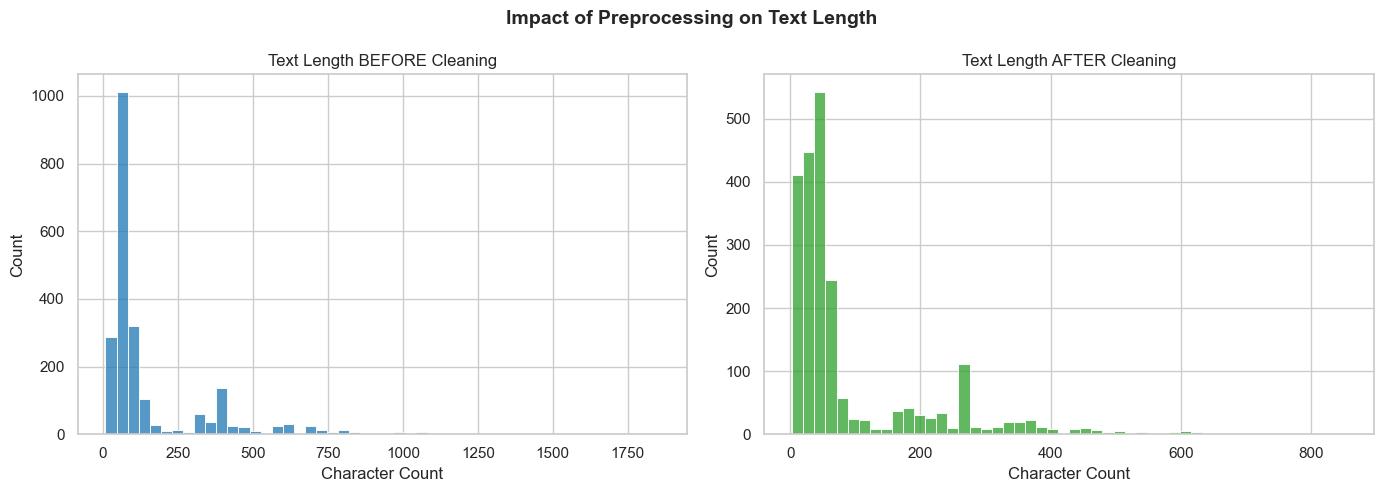

Avg length before: 164 chars
Avg length after:  93 chars
Reduction:         43.3%


In [ ]:
print("=== 3 TICKET COMPARISON: BEFORE vs AFTER ===\n")

for i in range(3):
    print(f"--- Ticket {i+1} ---")
    print(f"CATEGORY: {train_df[CATEGORY_TARGET].iloc[i]}")
    print(f"BEFORE: {str(train_df[TEXT_COLUMN].iloc[i])[:200]}")
    print(f"AFTER:  {train_clean[TEXT_COLUMN].iloc[i][:200]}")
    print()

In [ ]:
train_df["text_length"]     = train_df[TEXT_COLUMN].astype(str).apply(len)
train_clean["clean_length"] = train_clean[TEXT_COLUMN].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["text_length"], bins=50, ax=axes[0], color="#1f77b4")
axes[0].set_title("Text Length BEFORE Cleaning")
axes[0].set_xlabel("Character Count")

sns.histplot(train_clean["clean_length"], bins=50, ax=axes[1], color="#2ca02c")
axes[1].set_title("Text Length AFTER Cleaning")
axes[1].set_xlabel("Character Count")

plt.suptitle("Impact of Preprocessing on Text Length",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/text_length_before_after.png", dpi=150)
plt.show()

print(f"Avg length before: {train_df['text_length'].mean():.0f} chars")
print(f"Avg length after:  {train_clean['clean_length'].mean():.0f} chars")
reduction = (
    (train_df['text_length'].mean() - train_clean['clean_length'].mean())
    / train_df['text_length'].mean() * 100
)
print(f"Reduction:         {reduction:.1f}%")

Saved cleaned data to E:\Future ml projects\FUTURE_ML_02\data\processed\tickets_cleaned.csv
Shape: (2228, 3)
Columns: ['clean_text', 'category_truth', 'Ticket Priority']


In [ ]:
print("=== MISSING VALUES IN KEY COLUMNS ===")
for col in [TEXT_COLUMN, CATEGORY_TARGET]:
    missing = train_clean[col].isnull().sum()
    pct = (missing / len(train_clean)) * 100
    print(f"Train - {col:20s}: {missing} missing ({pct:.1f}%)")

for col in [TEXT_COLUMN, CATEGORY_TARGET]:
    missing = test_clean[col].isnull().sum()
    pct = (missing / len(test_clean)) * 100
    print(f"Test  - {col:20s}: {missing} missing ({pct:.1f}%)")

Tickets still containing 'please assist': 0

Sample clean ticket:
file share access


In [ ]:
# Confirm redaction tags and boilerplate are gone
checks = ["please assist", "[name]", "[ticket id]", "[company]", "[location]"]

print("=== BOILERPLATE REMOVAL VERIFICATION ===")
for phrase in checks:
    count = train_clean[TEXT_COLUMN].str.contains(
        phrase, case=False, na=False
    ).sum()
    print(f"'{phrase}' still present in: {count} tickets")

# You should see 0 for all checks. If not, add the pattern to BOILERPLATE_PHRASES in preprocessor.py.

In [ ]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save only the columns we need for ML
cols_to_save = [TEXT_COLUMN, CATEGORY_TARGET]

train_path = PROCESSED_DATA_DIR / "train_cleaned.csv"
test_path  = PROCESSED_DATA_DIR / "test_cleaned.csv"

train_clean[cols_to_save].to_csv(train_path, index=False)
test_clean[cols_to_save].to_csv(test_path,   index=False)

print(f"Train saved to: {train_path}")
print(f"Test saved to:  {test_path}")
print(f"\nTrain shape: {train_clean[cols_to_save].shape}")
print(f"Test shape:  {test_clean[cols_to_save].shape}")

In [ ]:
# Reload from disk and confirm files are correct
train_verify = pd.read_csv(train_path)
test_verify  = pd.read_csv(test_path)

print("=== FINAL VERIFICATION ===")
print(f"\nTrain loaded shape: {train_verify.shape}")
print(f"Test loaded shape:  {test_verify.shape}")

print(f"\nTrain columns: {train_verify.columns.tolist()}")
print(f"Test columns:  {test_verify.columns.tolist()}")

print(f"\nTrain category distribution:")
print(train_verify[CATEGORY_TARGET].value_counts())

print(f"\nSample clean ticket:")
print(train_verify[TEXT_COLUMN].iloc[4])

# If categories look correct and text is clean, you can proceed to feature engineering.